# Deep Learning Project – Fashion MNIST

## Fokusområde: Input och Preprocessing

Syftet med detta projekt är att undersöka hur preprocessing påverkar en deep learning-modell för bildklassificering.

Vi använder Fashion MNIST-datasetet som innehåller bilder av olika klädesplagg.

Projektet fokuserar på:

- att förstå datan
- att förbereda input-data
- att analysera hur preprocessing påverkar modellens prestanda

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist


I0000 00:00:1779545871.388062   37839 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779545871.388323   37839 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779545871.412342   37839 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779545871.977649   37839 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

# Ladda in datasetet

Fashion MNIST finns direkt inbyggt i Keras och kan laddas automatiskt.

Datasetet innehåller:

- 60 000 träningsbilder
- 10 000 testbilder
- 10 olika klasser
- gråskalebilder med storlek 28x28 pixlar

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Undersöka datasetets struktur

Vi börjar med att undersöka:

- hur många bilder som finns
- bildstorlek
- hur labels ser ut

In [3]:
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


# Klassnamn

Fashion MNIST innehåller 10 olika kategorier av kläder och accessoarer.

In [4]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# Visualisering av bilder

För att förstå datan bättre visualiserar vi några exempelbilder från datasetet.

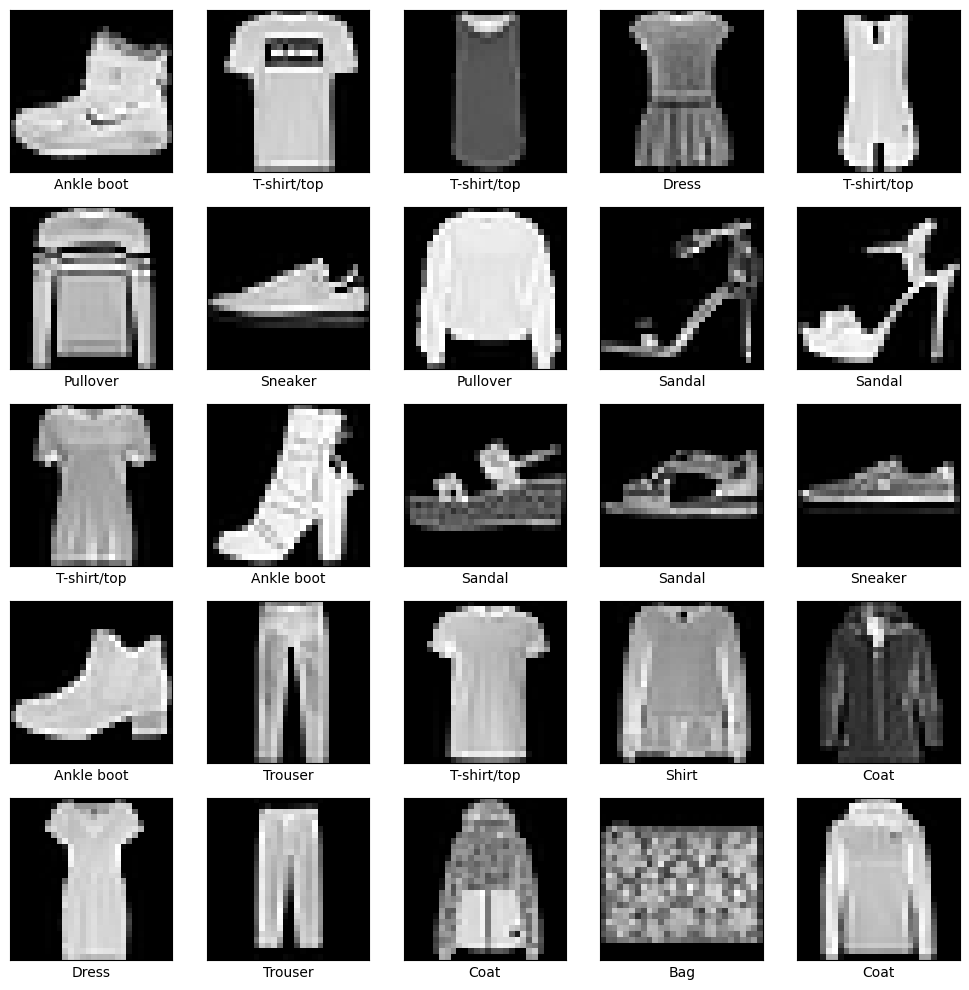

In [5]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(x_train[i], cmap='gray')
    plt.xlabel(class_names[y_train[i]])

plt.tight_layout()
plt.show()

# Analys av klassfördelning

Det är viktigt att kontrollera om datasetet är balanserat.

Om vissa klasser innehåller betydligt fler bilder än andra kan modellen bli biased.

In [6]:
unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{class_names[label]}: {count}")

T-shirt/top: 6000
Trouser: 6000
Pullover: 6000
Dress: 6000
Coat: 6000
Sandal: 6000
Shirt: 6000
Sneaker: 6000
Bag: 6000
Ankle boot: 6000


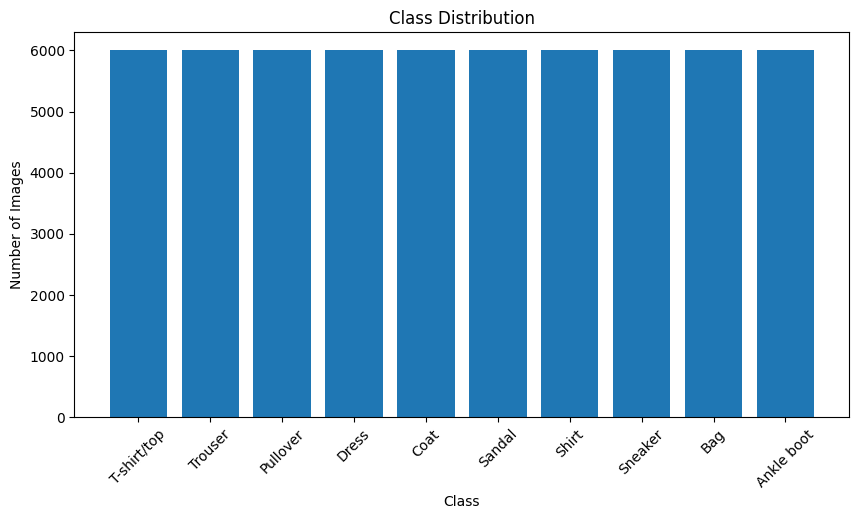

In [7]:
plt.figure(figsize=(10,5))

plt.bar(range(len(unique)), counts)

plt.xticks(range(len(unique)), class_names, rotation=45)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

# Analys av datasetet

Efter analysen kan vi se att:

- datasetet innehåller 10 klasser
- bilderna är gråskalebilder
- alla bilder har storleken 28x28
- datasetet är relativt balanserat

Detta är positivt eftersom balanserad data minskar risken för bias i modellen.

# Preprocessing av data

Innan datan används i en neural nätverksmodell behöver den preprocessas.

Preprocessing hjälper modellen att:

- träna stabilare
- lära sig snabbare
- förbättra prestanda

# Normalisering

Pixelvärden i bilderna ligger mellan 0 och 255.

Neurala nätverk fungerar bättre när värden skalas mellan 0 och 1.

Därför normaliserar vi bilderna genom att dividera varje pixel med 255.

# Fokusområde - Input och preprocessing

Det här området handlar om hur datan förbereds innan den används i modellen.  
Ni kan till exempel undersöka:  
normalisering av pixelvärden  
hur datan formas (reshaping)   
skillnaden mellan olika sätt att mata in data i modellen  
Målet är att förstå hur datans format och kvalitet påverkar modellens inlärning.  

Jämförelser:
1. Normaliserad vs onormaliserad data i dense-model
2. Normaliserad vs onormaliserad data i cnn-model
3. Reshape vs inte reshaped data i cnn-model (båda är nomaliserade)
4. Dense vs CNN: skillnaden mellan flattenad pixeldata och spatial bildrepresentation (cnn är reshaped och dense är nomaliserad)

## Model functions

In [8]:
def create_dense_model():
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=(28,28)),
        keras.layers.Dense(100, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [9]:
def create_cnn_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),

        keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),

        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## Plotting function

In [10]:
def plot_compare_acc_loss(_history1, _history2, _labels):
    plt.figure(figsize=(14, 5))

    # ---------------- ACCURACY ----------------
    plt.subplot(1, 2, 1)
    plt.plot(_history1.history['accuracy'], label=_labels[0])
    plt.plot(_history1.history['val_accuracy'], label=_labels[1])

    plt.plot(_history2.history['accuracy'], label=_labels[2])
    plt.plot(_history2.history['val_accuracy'], label=_labels[3])

    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # ---------------- LOSS ----------------
    plt.subplot(1, 2, 2)
    plt.plot(_history1.history['loss'], label=_labels[0])
    plt.plot(_history1.history['val_loss'], label=_labels[1])

    plt.plot(_history2.history['loss'], label=_labels[2])
    plt.plot(_history2.history['val_loss'], label=_labels[3])

    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.suptitle("Comparison between normalized and non-normalized data using Dense model")

    plt.tight_layout()
    plt.show()

    # ['Train Unnormalized', 'Val Unnormalized', 'Train Normalized', 'Val Normalized']

## Results function

In [11]:
results = []

def history_to_dict(_history, _name) -> dict:
    temp_results = {
        "model": _name,
        "train_accuracy": max(_history.history["accuracy"]),
        "val_accuracy": max(_history.history["val_accuracy"]),
        "train_loss": min(_history.history["loss"]),
        "val_loss": min(_history.history["val_loss"])
    }
    return temp_results

# Modeller

## 1. Normaliserad vs onormaliserad data i dense-model

In [12]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_train.astype('float32') / 255.0

print("Min pixel value:", x_train.min())
print("Max pixel value:", x_train.max())
print("Min pixel value normalised:", x_train_norm.min())
print("Max pixel value normalised:", x_train_norm.max())

model_dense = create_dense_model()
model_dense_norm = create_dense_model()

history_model_dense = model_dense.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)
results.append(history_to_dict(history_model_dense, "model_dense"))

history_model_dense_norm = model_dense_norm.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.2
)
results.append(history_to_dict(history_model_dense_norm, "model_dense_norm"))

Min pixel value: 0
Max pixel value: 255
Min pixel value normalised: 0.0
Max pixel value normalised: 1.0
Epoch 1/10


/home/markus/Desktop/Data Scientist/7. Deep Learning/3. Group Exam/Project/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1779545872.735182   37839 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6219 - loss: 3.9259 - val_accuracy: 0.6892 - val_loss: 0.9065
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7307 - loss: 0.7503 - val_accuracy: 0.7607 - val_loss: 0.6869
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7815 - loss: 0.6055 - val_accuracy: 0.7520 - val_loss: 0.6948
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7983 - loss: 0.5695 - val_accuracy: 0.8121 - val_loss: 0.5605
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8083 - loss: 0.5435 - val_accuracy: 0.8092 - val_loss: 0.5599
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8130 - loss: 0.5299 - val_accuracy: 0.8138 - val_loss: 0.5652
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8158 - loss: 0.5325 - val_accuracy: 0.8187 - val_loss: 0.5427
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8197 - loss: 0.5117 - val_accurac

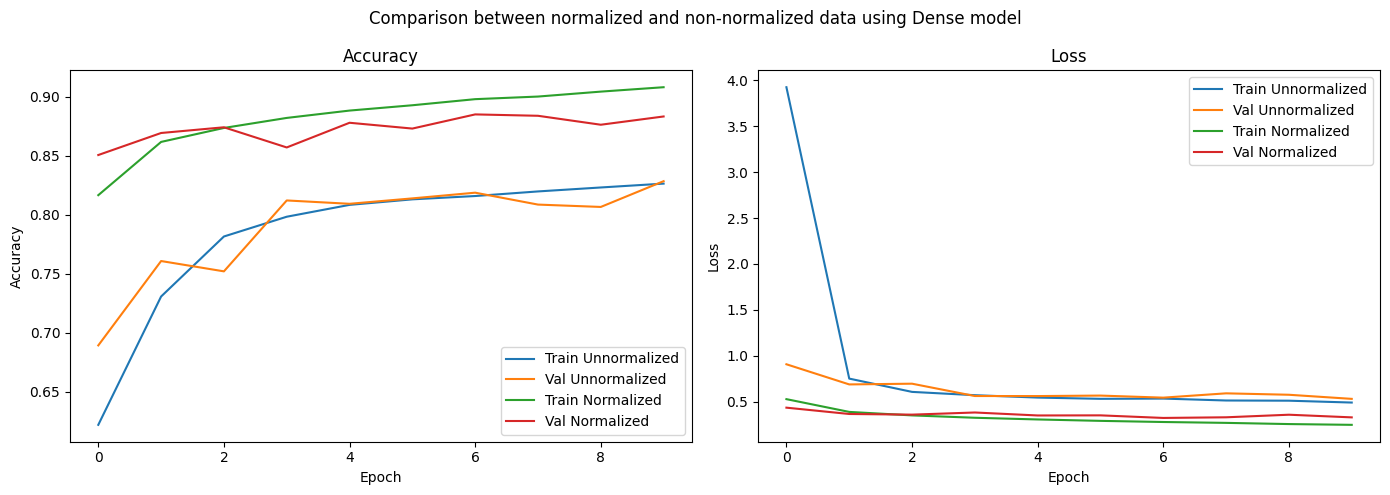

In [13]:
plot_compare_acc_loss(history_model_dense,
                      history_model_dense_norm,
                      ['Train Unnormalized', 'Val Unnormalized', 'Train Normalized', 'Val Normalized'])

## 2. Normaliserad vs onormaliserad data i cnn-model

In [14]:
model_cnn = create_cnn_model()
model_cnn_norm = create_cnn_model()

x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_train_cnn_norm = x_train_norm.reshape(-1, 28, 28, 1)

history_model_cnn = model_cnn.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.2
)
results.append(history_to_dict(history_model_cnn, "model_cnn"))

history_model_cnn_norm = model_cnn_norm.fit(
    x_train_cnn_norm,
    y_train,
    epochs=10,
    validation_split=0.2
)
results.append(history_to_dict(history_model_cnn_norm, "model_cnn_norm"))

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8409 - loss: 0.5593 - val_accuracy: 0.8711 - val_loss: 0.3609
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8945 - loss: 0.2906 - val_accuracy: 0.8964 - val_loss: 0.2838
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9087 - loss: 0.2502 - val_accuracy: 0.8952 - val_loss: 0.2875
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9166 - loss: 0.2280 - val_accuracy: 0.8988 - val_loss: 0.2893
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9231 - loss: 0.2069 - val_accuracy: 0.9045 - val_loss: 0.2732
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9298 - loss: 0.1913 - val_accuracy: 0.9015 - val_loss: 0.2969
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9341 - loss: 0.1772 - val_accuracy: 0.9051 - val_loss: 0.2724
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9410 - loss: 0.1573 - 

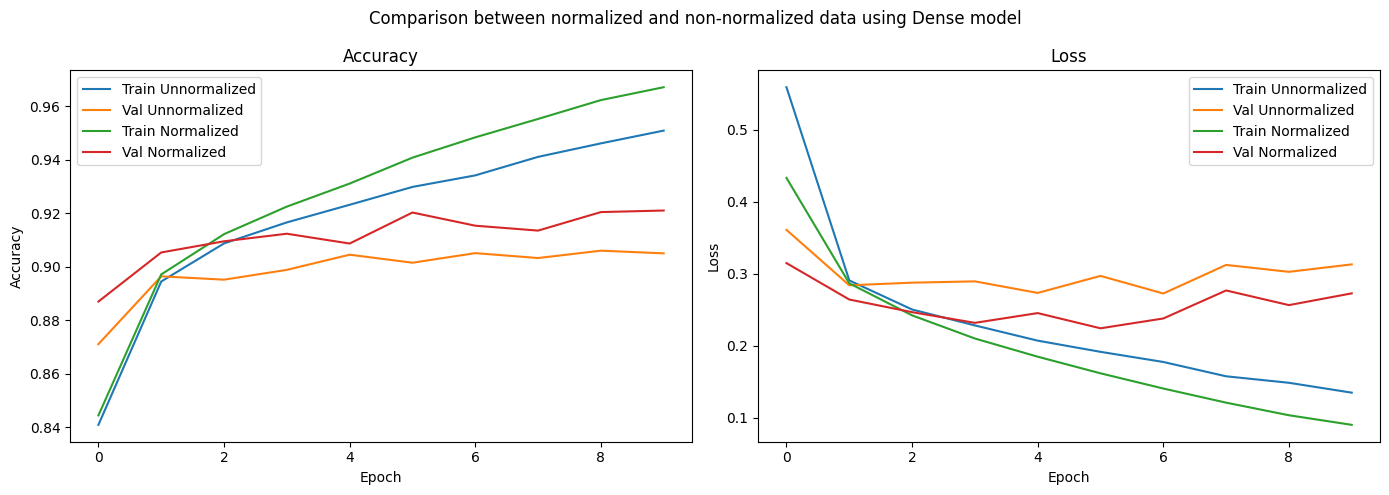

In [15]:
plot_compare_acc_loss(history_model_cnn,
                      history_model_cnn_norm,
                      ['Train Unnormalized', 'Val Unnormalized', 'Train Normalized', 'Val Normalized'])

## 3. Reshape vs inte reshaped data i cnn-model (båda är nomaliserade)

In [16]:
model_cnn_norm = create_cnn_model()
model_cnn_norm_reshape = create_cnn_model()

x_train_cnn_norm = x_train_norm
x_train_cnn_norm_reshape = x_train_norm.reshape(-1, 28, 28, 1)

history_model_cnn_norm = model_cnn_norm.fit(
    x_train_cnn_norm,
    y_train,
    epochs=10,
    validation_split=0.2
)

history_model_cnn_norm_reshape = model_cnn_norm_reshape.fit(
    x_train_cnn_norm_reshape,
    y_train,
    epochs=10,
    validation_split=0.2
)
results.append(history_to_dict(history_model_cnn_norm_reshape, "model_cnn_norm_reshape"))

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8384 - loss: 0.4555 - val_accuracy: 0.8764 - val_loss: 0.3450
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8924 - loss: 0.2975 - val_accuracy: 0.8976 - val_loss: 0.2801
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9070 - loss: 0.2531 - val_accuracy: 0.9117 - val_loss: 0.2503
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9191 - loss: 0.2199 - val_accuracy: 0.9134 - val_loss: 0.2422
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9292 - loss: 0.1913 - val_accuracy: 0.9146 - val_loss: 0.2373
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9386 - loss: 0.1676 - val_accuracy: 0.9207 - val_loss: 0.2299
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9452 - loss: 0.1477 - val_accuracy: 0.9170 - val_loss: 0.2332
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9531 - loss: 0.1275 - 

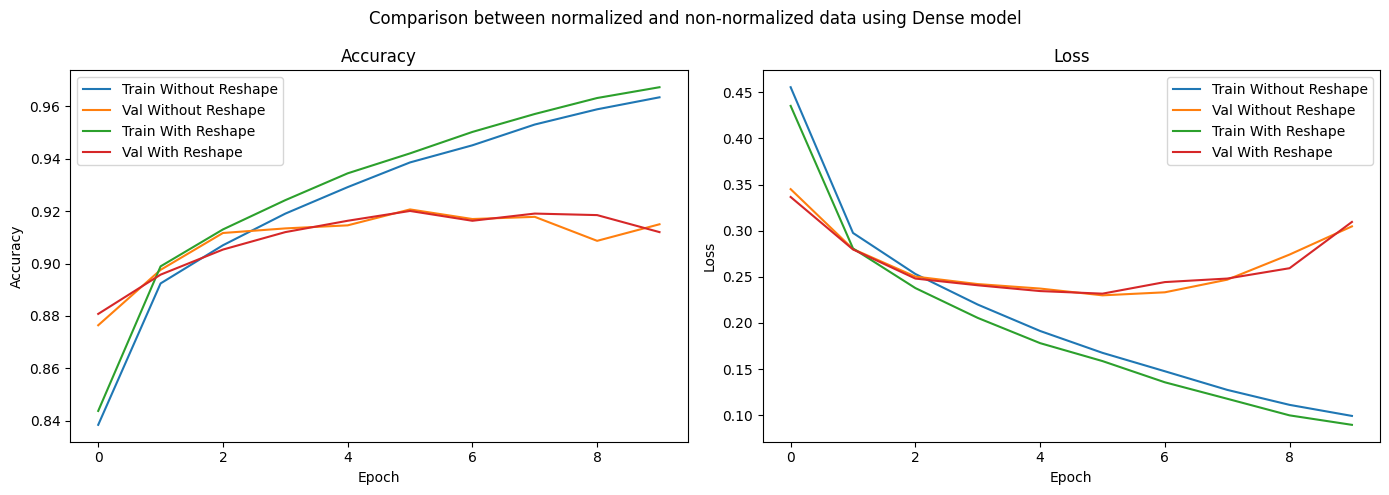

In [17]:
plot_compare_acc_loss(history_model_cnn_norm,
                      history_model_cnn_norm_reshape,
                      ['Train Without Reshape', 'Val Without Reshape', 'Train With Reshape', 'Val With Reshape'])

## 4. Dense vs CNN: skillnaden mellan flattenad pixeldata och spatial bildrepresentation (cnn är reshaped och dense är nomaliserad)

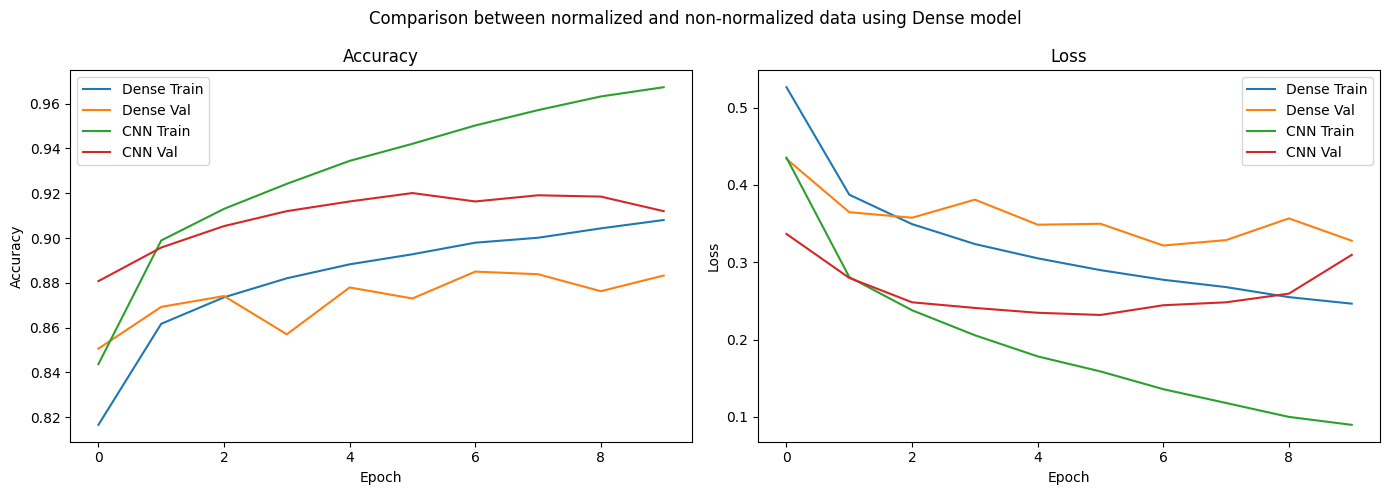

In [18]:
plot_compare_acc_loss(history_model_dense_norm,
                      history_model_cnn_norm_reshape,
                      ['Dense Train', 'Dense Val', 'CNN Train', 'CNN Val'])

# Comparing all models at once

In [29]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("val_accuracy", ascending=False).reset_index(drop=True)

display(results_df)

,model,train_accuracy,val_accuracy,train_loss,val_loss
0,model_cnn_norm,0.967062,0.921000,0.089796,0.224039
1,model_cnn_norm_reshape,0.967354,0.920083,0.089600,0.231761
2,model_cnn,0.950854,0.906000,0.134533,0.272420
3,model_dense_norm,0.908042,0.885000,0.246383,0.321571
4,model_dense,0.826354,0.828417,0.489262,0.529465


Resultatet från denna tabell visar att den normaliserade cnn modellen och den normaliserade cnn modellen med reshaping är i princip lika bra. Normalisering ger en förbättring på alla modeller.

# Slutsats

I denna del av projektet har vi:

- undersökt datasetet
- analyserat klassfördelning
- normaliserat bilderna
- förberett datan för CNN-modellen

Preprocessing är viktigt eftersom kvaliteten på input-data påverkar modellens resultat.

## Träna modellen

I denna del tränas CNN-modellen på träningsdatan. Vi använder `x_train` och `y_train` som träningsdata.

Vi använder också `validation_split=0.2`, vilket betyder att 20 procent av träningsdatan används som valideringsdata. Det gör att vi kan följa hur modellen presterar på data som den inte tränas direkt på.

Modellen tränas i 10 epoker. En epok betyder att modellen går igenom hela träningsdatan en gång. Genom att följa `accuracy`, `loss`, `val_accuracy` och `val_loss` kan vi se om modellen förbättras över tid.

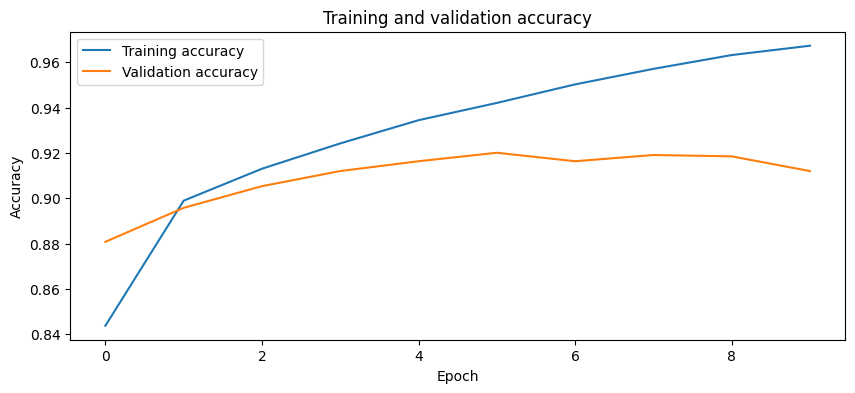

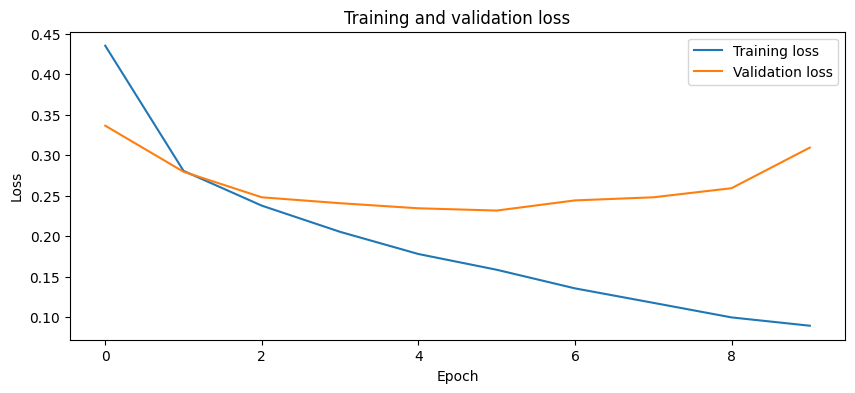

In [20]:
# Visualisera accuracy och loss

plt.figure(figsize=(10, 4))

plt.plot(history_model_cnn_norm_reshape.history['accuracy'], label='Training accuracy')
plt.plot(history_model_cnn_norm_reshape.history['val_accuracy'], label='Validation accuracy')

plt.title('Training and validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))

plt.plot(history_model_cnn_norm_reshape.history['loss'], label='Training loss')
plt.plot(history_model_cnn_norm_reshape.history['val_loss'], label='Validation loss')

plt.title('Training and validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Analys av träningen

Under träningen följer vi hur modellens accuracy och loss förändras över tid.

I vårt resultat ökade training accuracy till ungefär 95 %, medan validation accuracy stabiliserades runt 92 %. Detta visar att modellen lär sig träningsdatan bra samtidigt som den fortfarande presterar stabilt på ny data. Skillnaden mellan training och validation accuracy tyder på viss overfitting mot slutet av träningen, men modellen generaliserar fortfarande relativt bra.